#### importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix, 
                             roc_auc_score, precision_recall_curve, auc, average_precision_score)
from sklearn.decomposition import PCA

# importing imblearn
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    print("imblearn successfully imported.")
except ImportError:
    print("Please install imbalanced-learn: pip install imbalanced-learn")


imblearn successfully imported.


In [2]:
# Loading data set
df = pd.read_csv('data.csv')

#### Data Exploration

In [3]:
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Columns: 1204 entries, MATS3v to Class
dtypes: float64(1003), int64(200), object(1)
memory usage: 1.6+ MB
None


In [4]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
   MATS3v  nHBint10  MATS3s  MATS3p  nHBDon_Lipinski  minHBint8  MATS3e  \
0  0.0908         0  0.0075  0.0173                0        0.0 -0.0436   
1  0.0213         0  0.1144 -0.0410                0        0.0  0.1231   
2  0.0018         0 -0.0156 -0.0765                2        0.0 -0.1138   
3 -0.0251         0 -0.0064 -0.0894                3        0.0 -0.0747   
4  0.0135         0  0.0424 -0.0353                0        0.0 -0.0638   

   MATS3c  minHBint2  MATS3m  ...   WTPT-4   WTPT-5  ETA_EtaP_L  ETA_EtaP_F  \
0  0.0409        0.0  0.1368  ...   0.0000   0.0000      0.1780      1.5488   
1 -0.0316        0.0  0.1318  ...   8.8660  19.3525      0.1739      1.3718   
2 -0.1791        0.0  0.0615  ...   5.2267  27.8796      0.1688      1.4395   
3 -0.1151        0.0  0.0361  ...   7.7896  24.7336      0.1702      1.4654   
4  0.0307        0.0  0.0306  ...  12.3240  19.7486      0.1789      1.4495   

   ETA_EtaP_B  nT5Ring  SHdNH  ETA_dEpsilon_C  MDEO-22     

In [5]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
           MATS3v    nHBint10      MATS3s      MATS3p  nHBDon_Lipinski  \
count  171.000000  171.000000  171.000000  171.000000       171.000000   
mean    -0.031244    0.315789   -0.001001   -0.061501         0.994152   
std      0.063559    0.762918    0.063928    0.072891         1.108773   
min     -0.311500    0.000000   -0.184600   -0.348500         0.000000   
25%     -0.066700    0.000000   -0.036000   -0.099550         0.000000   
50%     -0.032500    0.000000   -0.002000   -0.059400         1.000000   
75%      0.004850    0.000000    0.029000   -0.017100         2.000000   
max      0.141100    4.000000    0.218100    0.129000         6.000000   

        minHBint8      MATS3e      MATS3c   minHBint2      MATS3m  ...  \
count  171.000000  171.000000  171.000000  171.000000  171.000000  ...   
mean     0.677770   -0.025418   -0.053289    1.569251    0.003226  ...   
std      1.647322    0.078645    0.109463    2.497362    0.074076  ...   
min      0.00000

In [6]:
# Check for missing values
print("\nMissing values per column (top 20):")
print(df.isnull().sum().sort_values(ascending=False).head(20))


Missing values per column (top 20):
Class        0
MATS3v       0
nHBint10     0
MATS3s       0
AATSC1e      0
AATSC1c      0
AATSC1m      0
AATSC1v      0
AATSC1s      0
VE1_D        0
nsCl         0
VE3_D        0
nHBAcc       0
maxHaaCH     0
VE1_Dt       0
nssNH        0
ndS          0
ndO          0
topoShape    0
minsssN      0
dtype: int64


In [7]:
# Check column names to find the target
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['MATS3v', 'nHBint10', 'MATS3s', 'MATS3p', 'nHBDon_Lipinski', 'minHBint8', 'MATS3e', 'MATS3c', 'minHBint2', 'MATS3m', 'minHBint6', 'minHBint7', 'minHBint4', 'MATS3i', 'VR3_Dt', 'SpMax8_Bhi', 'SdsN', 'SpMax8_Bhm', 'SpMax8_Bhe', 'ECCEN', 'MDEC-14', 'SpMax8_Bhs', 'SpMax8_Bhp', 'SpMax8_Bhv', 'MDEC-11', 'MDEC-12', 'MDEC-13', 'VR2_Dt', 'BIC5', 'ATS7s', 'ATS7p', 'ATS7v', 'ATS7i', 'ATS7m', 'ATS7e', 'mintN', 'nHsNH2', 'khs.sssCH', 'minHBint3', 'maxdssC', 'nT6Ring', 'minHBint5', 'nF8Ring', 'minssCH2', 'SpMax_DzZ', 'ETA_EtaP', 'nHsOH', 'SpMin1_Bhe', 'maxHother', 'nHBAcc_Lipinski', 'StN', 'khs.aaS', 'khs.aaO', 'khs.aaN', 'Sare', 'SHAvin', 'SpMax3_Bhv', 'SpMax3_Bhp', 'SpMax3_Bhs', 'SpMax3_Bhe', 'SpMin6_Bhi', 'SpMax3_Bhm', 'SpMax3_Bhi', 'ETA_EtaP_F_L', 'mindCH2', 'AATSC2e', 'AATSC2c', 'AATSC2m', 'AATSC2i', 'nsBr', 'AATS5p', 'AATSC2v', 'AATSC2p', 'AATSC2s', 'VABC', 'maxdNH', 'khs.ddsN', 'RotBtFrac', 'ATS4e', 'ATS4m', 'nFRing', 'ATS4i', 'EE_DzZ', 'ATS4s', 'ATS4p', 'ETA_Alpha', 'khs.sssN

In [8]:
# Check unique values in the target column
print("Target column unique values:")
print(df['Class'].value_counts())

Target column unique values:
Class
NonToxic    115
Toxic        56
Name: count, dtype: int64


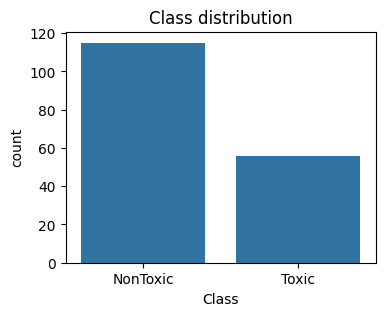

In [9]:
# Plot class distribution
plt.figure(figsize=(4, 3))
sns.countplot(x='Class', data=df)
plt.title('Class distribution')
plt.show()

In [10]:
# Check for total missing values
total_missing = df.isnull().sum().sum()
print(f"\nTotal missing values in the dataset: {total_missing}")


Total missing values in the dataset: 0


In [11]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [12]:
# Identify columns with zero variance (all values are the same)
zero_variance_cols = [col for col in df.columns if df[col].nunique() <= 1]
print(f"Number of columns with zero variance: {len(zero_variance_cols)}")

Number of columns with zero variance: 0


In [13]:
# Identify non-numeric columns besides the target
non_numeric_cols = df.select_dtypes(exclude=['number']).columns.tolist()
print(f"Non-numeric columns: {non_numeric_cols}")

Non-numeric columns: ['Class']


In [14]:
# Let's drop columns with very low variance (redundant features)
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)
X_initial = df.drop('Class', axis=1)
X_clean = selector.fit_transform(X_initial)
dropped_cols = X_initial.columns[~selector.get_support()]
print(f"Dropped {len(dropped_cols)} low-variance columns.")

Dropped 209 low-variance columns.


##### Encoding

In [15]:
le = LabelEncoder()
y = le.fit_transform(df['Class']) # NonToxic: 0, Toxic: 1
print(f"Classes: {le.classes_}")

Classes: ['NonToxic' 'Toxic']


In [16]:
X = pd.DataFrame(X_clean, columns=X_initial.columns[selector.get_support()])

#### Train Test Split 

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [18]:
# Random Forest Pipeline with PCA and SMOTE
rf_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42)), # Feature Engineering: PCA
    ('smote', SMOTE(random_state=42)),               # Resampling: SMOTE
    ('rf', RandomForestClassifier(random_state=42))
])



In [19]:
# SVC Pipeline with PCA and SMOTE
svc_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('smote', SMOTE(random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
])



In [20]:
# HistGradientBoosting Pipeline with PCA and SMOTE
hgb_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('smote', SMOTE(random_state=42)),
    ('hgb', HistGradientBoostingClassifier(random_state=42))
])



In [21]:
# Hyperparameter grids
rf_param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20],
}

svc_param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__kernel': ['linear', 'rbf']
}

hgb_param_grid = {
    'hgb__learning_rate': [0.01, 0.1],
    'hgb__max_iter': [100, 200]
}

In [22]:
# Grid Search focusing on Precision-Recall (Average Precision)
def tune_model(pipe, grid, X_train, y_train):
    # Using 'average_precision' as the scoring metric for imbalanced data
    grid_search = GridSearchCV(pipe, grid, cv=5, scoring='average_precision', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    return grid_search



Fitting 5 folds for each of 6 candidates, totalling 30 fits


--- Random Forest Results ---
Best Params: {'rf__max_depth': 10, 'rf__n_estimators': 100}
Accuracy: 0.5143
PR-AUC: 0.3108
Average Precision: 0.3450
              precision    recall  f1-score   support

    NonToxic       0.63      0.71      0.67        24
       Toxic       0.12      0.09      0.11        11

    accuracy                           0.51        35
   macro avg       0.38      0.40      0.39        35
weighted avg       0.47      0.51      0.49        35

[[17  7]
 [10  1]]


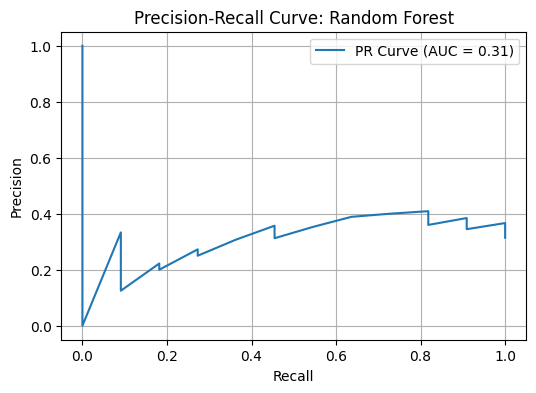

Fitting 5 folds for each of 6 candidates, totalling 30 fits
--- SVC Results ---
Best Params: {'svc__C': 1, 'svc__kernel': 'rbf'}
Accuracy: 0.5714
PR-AUC: 0.3032
Average Precision: 0.3401
              precision    recall  f1-score   support

    NonToxic       0.67      0.75      0.71        24
       Toxic       0.25      0.18      0.21        11

    accuracy                           0.57        35
   macro avg       0.46      0.47      0.46        35
weighted avg       0.54      0.57      0.55        35

[[18  6]
 [ 9  2]]


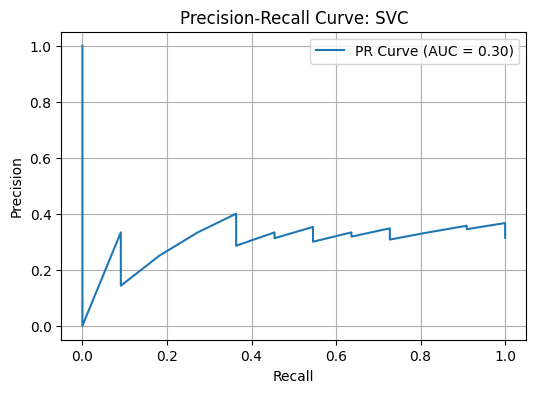

Fitting 5 folds for each of 4 candidates, totalling 20 fits
--- HistGradientBoosting Results ---
Best Params: {'hgb__learning_rate': 0.01, 'hgb__max_iter': 100}
Accuracy: 0.5714
PR-AUC: 0.3196
Average Precision: 0.3640
              precision    recall  f1-score   support

    NonToxic       0.68      0.71      0.69        24
       Toxic       0.30      0.27      0.29        11

    accuracy                           0.57        35
   macro avg       0.49      0.49      0.49        35
weighted avg       0.56      0.57      0.57        35

[[17  7]
 [ 8  3]]


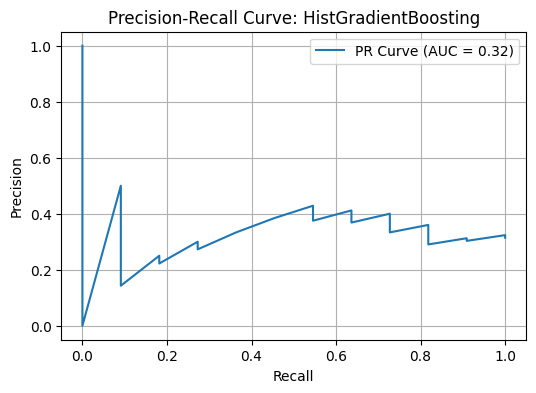

In [23]:
# Model Evaluation focusing on Precision-Recall
def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"--- {name} Results ---")
    print(f"Best Params: {model.best_params_}")
    
    # Calculate PR-AUC
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    avg_precision = average_precision_score(y_test, y_prob)
    
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    print(f"Average Precision: {avg_precision:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    print(confusion_matrix(y_test,y_pred))
    
    # Plot PR Curve
    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve: {name}')
    plt.legend()
    plt.grid(True)
    plt.show()

# Run tuning and evaluation
rf_gs = tune_model(rf_pipe, rf_param_grid, X_train, y_train)
evaluate(rf_gs, X_test, y_test, "Random Forest")

svc_gs = tune_model(svc_pipe, svc_param_grid, X_train, y_train)
evaluate(svc_gs, X_test, y_test, "SVC")

hgb_gs = tune_model(hgb_pipe, hgb_param_grid, X_train, y_train)
evaluate(hgb_gs, X_test, y_test, "HistGradientBoosting")



In [ ]:
# Predictions for all models
test_samples = X_test.head(10)
actual_labels = le.inverse_transform(y_test[:10])

print(f"{'Actual':<15} | {'RF Pred':<15} | {'SVC Pred':<15} | {'HGB Pred':<15}")
print("-" * 65)

rf_preds = le.inverse_transform(rf_gs.predict(test_samples))
svc_preds = le.inverse_transform(svc_gs.predict(test_samples))
hgb_preds = le.inverse_transform(hgb_gs.predict(test_samples))

for actual, rf, svc, hgb in zip(actual_labels, rf_preds, svc_preds, hgb_preds):
    print(f"{actual:<15} | {rf:<15} | {svc:<15} | {hgb:<15}")


Actual          | RF Pred         | SVC Pred        | HGB Pred       
-----------------------------------------------------------------
NonToxic        | NonToxic        | Toxic           | NonToxic       
NonToxic        | NonToxic        | NonToxic        | NonToxic       
Toxic           | NonToxic        | NonToxic        | NonToxic       
NonToxic        | NonToxic        | NonToxic        | NonToxic       
Toxic           | NonToxic        | NonToxic        | NonToxic       
Toxic           | NonToxic        | NonToxic        | Toxic          
NonToxic        | NonToxic        | NonToxic        | NonToxic       
NonToxic        | NonToxic        | NonToxic        | NonToxic       
NonToxic        | Toxic           | Toxic           | Toxic          
NonToxic        | Toxic           | Toxic           | Toxic          
